#Project Title: Global Startup Unicorn Analysis(2025)

#Dataset Columns
    1.Startup
    2.Valuation ($B)
    3.Date Joined (unicorn date)
    4.Country
    5.City
    6.Industry
    7.Select Investors


---


```



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Read Excel and use first row as header (row 1 in Excel)
df = pd.read_excel('/content/CB-Insights_Global-Unicorn-Club_2025.xlsx',header=1)

# Drop the first column if you don’t need it
df1 = df.drop(df.columns[0], axis=1)

# Rename columns
df1.columns = ['Startup', 'Valuation ($B)', 'Date Joined','Country', 'City', 'Industry', 'Select Investors']

# Drop the first row
data1 = df1.drop(index=0).reset_index(drop=True)


#1. Data Cleaning
    #.Handle missing values
    #.Convert Valuation ($B) to numeric
    #.Format Date Joined to date type
    #.Standardize country/city names



In [2]:
#.Handle missing values
data=data1.dropna().copy()
data=data[data['Industry']!='West Palm Beach']
data.isnull().sum()
#.Convert Valuation ($B) to numeric
data['Valuation ($B)']=pd.to_numeric(data['Valuation ($B)'],errors="coerce")
 #.Format Date Joined to date type
data['Date Joined']=pd.to_datetime(data['Date Joined'],errors='coerce')
#.Standardize country/city names
data['Country']=data['Country'].str.strip().str.title()
data['City']=data['City'].str.strip().str.title()

#2. Feature Engineering
    @.Extract Year, Month from Date Joined
    @.Create Startup Age (years)
    @.Count number of investors
    @.Categorize valuation into ranges


In [3]:

# Extract year and month
data=data.copy()
data['Year_joined'] = data['Date Joined'].dt.year
data['Month_joined'] = data['Date Joined'].dt.month

# Reference date: July 8, 2025
ref_date = pd.to_datetime('2025-07-08')

# Calculate Startup Age (years)
data['Startup_age'] = (ref_date - data['Date Joined']).dt.days / 365
data['Startup_age'] = data['Startup_age'].round(1)
 #.Count number of investors
# Replace NaN with empty string first
data['Select Investors'] = data['Select Investors'].fillna("")

# Count investors by splitting on commas
data['Investor_count'] = data['Select Investors'].apply(lambda x: len(x.split(",")) if x != "" else 0)
# Categorize valuation into ranges
bins=[1,100,200,300,400,500]
labels=['1-100B','100-200B','200-300B','300-400B','400-500B']
data['Valuation_range']=pd.cut(data['Valuation ($B)'],bins=bins,labels=labels,include_lowest=True)

###Geography-Based Questions
   * 1. Which country has the highest number of startups?
   * 2. Which top 5 countries dominate unicorn creation?
   * 3. Which city produces the most startups?
   * 4. What is the average valuation per country?
   * 5. Which country has the highest average startup valuation?
   * 6. Which emerging countries show rapid growth?
   * 7. What percentage of startups come from the USA?
   * 8. Which cities are emerging startup hubs?
   * 9. Do certain countries specialize in certain industries?

In [4]:
#.Which country has the highest number of startups?
startup=data['Country'].value_counts().head(1)
print('1.Country with the highest number of statrtup',startup)
#Which top 5 countries dominate unicorn creation?
unicorn_dominate=data['Country'].value_counts().head(5)
print('2.Top 5 countries dominate unicorn creation:',unicorn_dominate)
#Which city produces the most startups?
citys=data['City'].value_counts().head(1)
print('3.The most that produces the most startup:',citys)
#What is the average valuation per country?
avg_value_country=data.groupby('Country')['Valuation ($B)'].mean().sort_values(ascending=False).head(5)
print('4.Average valuation per country',avg_value_country)
#Which country has the highest average startup valuation?
highest_avg_startup=data.groupby('Country')['Valuation ($B)'].mean().sort_values(ascending=False).head(1)
print('5.The highest average startup valuation',highest_avg_startup)
#Which emerging countries show rapid growth?
   # Count startups per country per year
growth=data.groupby(['Country','Year_joined']).size().reset_index(name='Count')
   # Calculate year-over-year growth
growth['YoY Growth']=growth.groupby('Country')['Count'].pct_change()
f=growth[growth['Year_joined']>=2020].groupby('Country')['YoY Growth'].mean().sort_values(ascending=False)
print('6.Countries showing radip growth',f.head(5))
#What percentage of startups come from the USA?
total_startup=len(data)
usa_startup=(data['Country']=='United States').sum()
g=round((usa_startup/total_startup)*100,2)
print(' 7.The percentage of startups come from the USA is ',g)
#Which cities are emerging startup hubs?
 # Count startups per city per year
growth1=data.groupby(['City','Year_joined']).size().reset_index(name='Count')
   # Calculate year-over-year growth
growth1['YoY Growth']=growth1.groupby('City')['Count'].pct_change()
h=growth1[growth1['Year_joined']>=2020].groupby('City')['YoY Growth'].mean().sort_values(ascending=False)
print('8.City showing radip growth',h.head(5))
#Do certain countries specialize in certain industries?
specialize=pd.crosstab(data['Country'],data['Industry'])
i=specialize.div(specialize.sum(axis=1), axis=0) * 100
print('9.countries specialize in certain industries',i.head(5))




1.Country with the highest number of statrtup Country
United States    710
Name: count, dtype: int64
2.Top 5 countries dominate unicorn creation: Country
United States     710
China             154
India              63
United Kingdom     56
Germany            31
Name: count, dtype: int64
3.The most that produces the most startup: City
San Francisco    194
Name: count, dtype: int64
4.Average valuation per country Country
Seychelles       10.000000
Australia         5.426667
Estonia           4.950000
United States     4.748099
China             4.453182
Name: Valuation ($B), dtype: float64
5.The highest average startup valuation Country
Seychelles    10.0
Name: Valuation ($B), dtype: float64
6.Countries showing radip growth Country
Canada         2.845238
India          1.644444
Spain          1.000000
Switzerland    1.000000
Mexico         0.966667
Name: YoY Growth, dtype: float64
 7.The percentage of startups come from the USA is  56.85
8.City showing radip growth City
Chicago       

###Startup & Valuation Questions
  * 1.  What is the average valuation of all startups?
  * 2. What is the median valuation?
  * 3. Which startup has the highest valuation?
  * 4. Which startup has the lowest valuation?
  * 5. How many startups exceed $50B valuation?
  * 6. What is the valuation distribution (low/mid/high)?
  * 7. Is there a trend of increasing valuations over time?
  * 8. Which industries have the highest average valuation?
  * 9. Do newer startups have higher valuations?
    


1.The average valuation of all startups 4.05
2.The median of the valuation 1.6
3.Startup with highest valuation: OpenAI - 500.0
4.Startup with lowest valuation: Contrast Security - 1.0
5.startups exceed $50B valuation: 7
6.The valuation distribution (low/mid/high) Valuation_range
1-100B      1245
100-200B       1
200-300B       1
300-400B       1
400-500B       1
Name: count, dtype: int64
7.Trend of increasing valuations over time Year_joined
2007      1.380000
2012    108.750000
2013      3.333333
2014      9.500000
2015      2.801724
2016      4.243125
2017     12.652903
2018      5.196543
2019     11.192353
2020      3.791648
2021      2.448473
2022      1.827409
2023      5.360545
2024      3.869351
2025      1.778382
Name: Valuation ($B), dtype: float64
8.Industries have the highest average valuation Industry
Media & Entertainment         6.677195
Enterprise Tech               4.744921
Industrials                   4.654134
Financial Services            3.551106
Consumer & Retail 

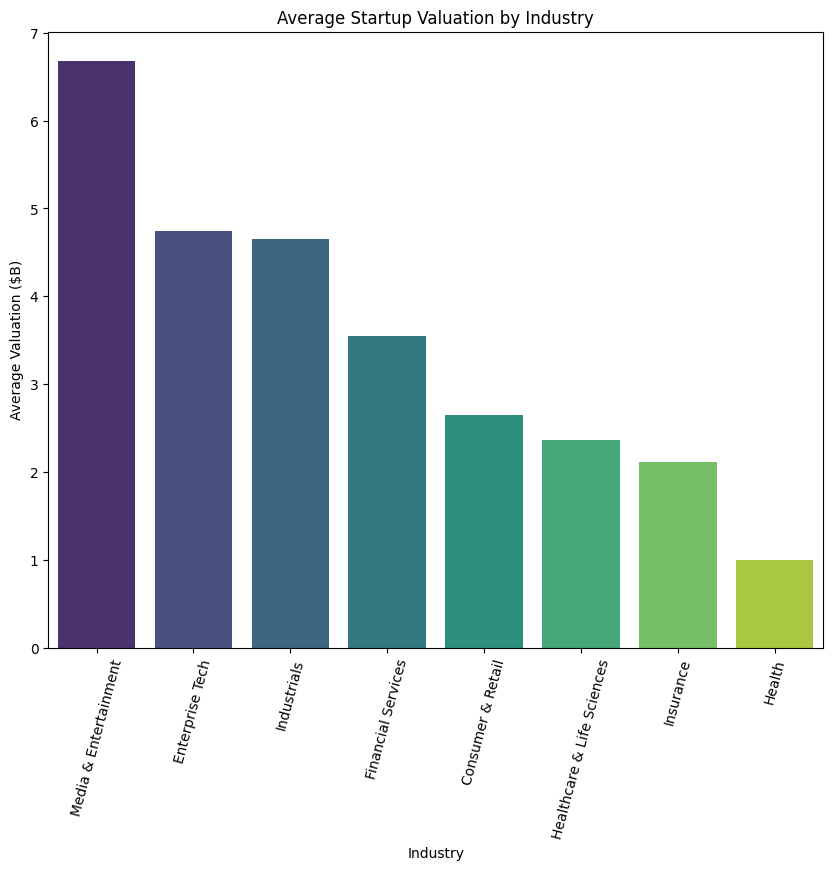

9.Correlation between age and valuation: -0.12397756303846846
#Negative → newer startups (lower age) tend to have higher valuations.


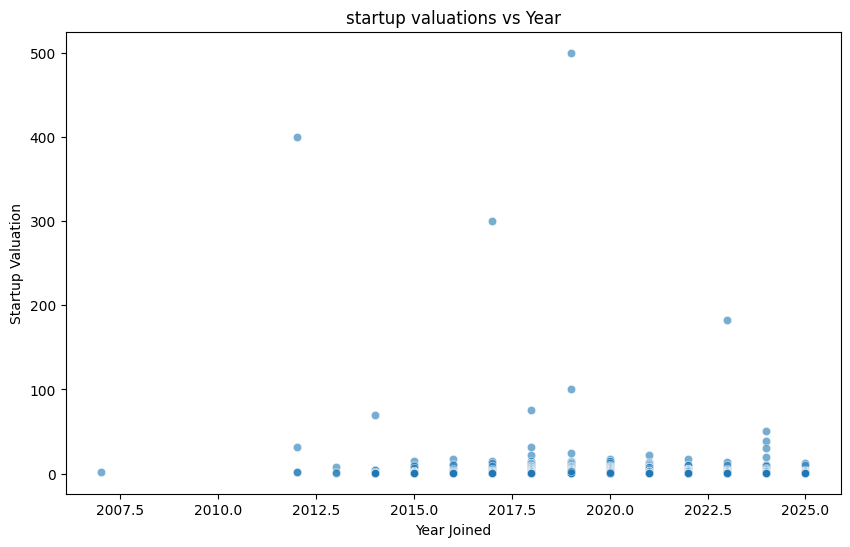

In [5]:
#What is the average valuation of all startups?
overall_avg=round(data['Valuation ($B)'].mean(),2)
print('1.The average valuation of all startups',overall_avg)
# What is the median valuation?
median=data['Valuation ($B)'].median()
print('2.The median of the valuation',median)
#.Which startup has the highest valuation?
high_val = data.groupby('Startup')['Valuation ($B)'].max().sort_values(ascending=False)
print("3.Startup with highest valuation:", high_val.index[0], "-", high_val.iloc[0])
#Which startup has the lowest valuation?
low_val = data.groupby('Startup')['Valuation ($B)'].min().sort_values(ascending=True)
print("4.Startup with lowest valuation:", low_val.index[0], "-", low_val.iloc[0])
#How many startups exceed $50B valuation?
val=data[data['Valuation ($B)']>50].shape[0] #.shape[0] gives the number of rows
print('5.startups exceed $50B valuation:',val)
#What is the valuation distribution (low/mid/high)?
dist=data['Valuation_range'].value_counts().sort_index()
print('6.The valuation distribution (low/mid/high)',dist)
#Is there a trend of increasing valuations over time?
trend = data.groupby('Year_joined')['Valuation ($B)'].mean()
print('7.Trend of increasing valuations over time',trend)
#Which industries have the highest average valuation?
avg_val=data.groupby('Industry')['Valuation ($B)'].mean().sort_values(ascending=False)
print('8.Industries have the highest average valuation',avg_val)
plt.figure(figsize=(10,8))
sns.barplot(x=avg_val.index, y=avg_val.values,hue=avg_val.index, palette="viridis")
plt.xticks(rotation=75)
plt.title("Average Startup Valuation by Industry")
plt.ylabel("Average Valuation ($B)")
plt.xlabel("Industry")
plt.show()

#Do newer startups have higher valuations?
corr=data['Year_joined'].corr(data['Valuation ($B)'])
print("9.Correlation between age and valuation:", corr)
print('#Negative → newer startups (lower age) tend to have higher valuations.')
plt.figure(figsize=(10,6))
sns.scatterplot(x=data['Year_joined'],y=data['Valuation ($B)'],alpha=0.6)
plt.title('startup valuations vs Year')
plt.xlabel('Year Joined')
plt.ylabel('Startup Valuation')
plt.show()


 ### Industry-Based Questions
 * 1.  Which industry has the most startups?
 * 2.  Which industry has the least startups?
 * 3.  Which industries are growing fastest?
 * 4.  Find The lead country for each industry?
 * 5.  what percentage of startups belong to tech
 * 6.  How diversified is the startup ecosystem?


1.Industry has the most startups: Industry
Enterprise Tech    441
Name: Startup, dtype: int64
2.Industry has the least startups: Industry
Insurance    24
Health        1
Name: Startup, dtype: int64
3.Industries are growing fastest:                             startup_count   avg_val
Industry                                           
Enterprise Tech                       441  4.744921
Financial Services                    208  3.551106
Consumer & Retail                     197  2.652437
Industrials                           179  4.654134
Healthcare & Life Sciences            117  2.362222
Media & Entertainment                  82  6.677195
Insurance                              24  2.111667
Health                                  1  1.000000
4.The lead country for each industry                      Industry        Country  Startup_Count
0           Consumer & Retail  United States             71
1             Enterprise Tech  United States            305
2          Financial Services  

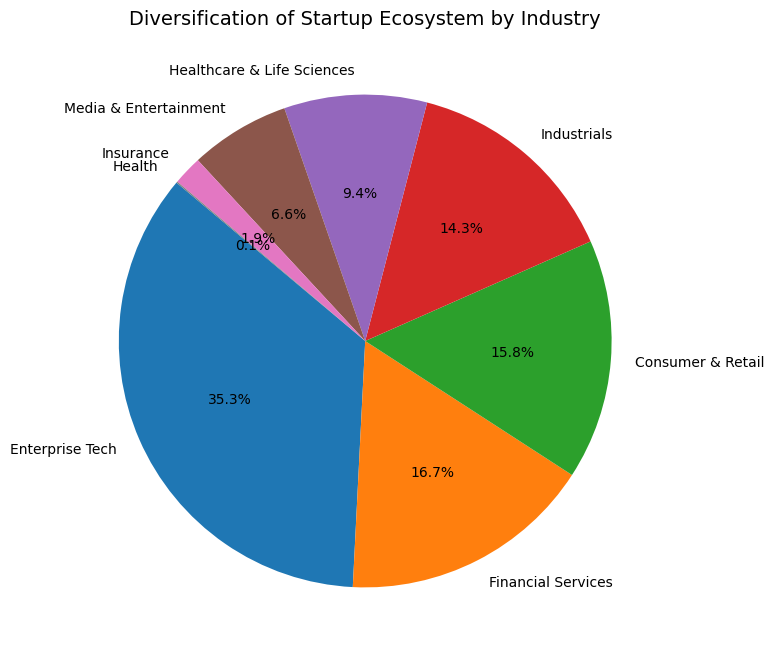

In [6]:
#Which industry has the most startups?
industry=data.groupby('Industry')['Startup'].count().sort_values(ascending=False)
print('1.Industry has the most startups:',industry.head(1))
#Which industry has the least startups?
print('2.Industry has the least startups:',industry.tail(2))
#Which industries are growing fastest?
industry_growth=data.groupby('Industry').agg(startup_count=('Startup','count'),
                                            avg_val=('Valuation ($B)','mean'))
industry_growth=industry_growth.sort_values(by='startup_count',ascending=False)
print('3.Industries are growing fastest:',industry_growth)
# find the lead country for each industry?
# Count startups by Industry and Country
industry_country_counts = (
    data.groupby(["Industry", "Country"])
      .size()
      .reset_index(name="Startup_Count")
)

# For each industry, find the country with the maximum startups
lead_country = (
    industry_country_counts.loc[
        industry_country_counts.groupby("Industry")["Startup_Count"].idxmax()
    ]
    .reset_index(drop=True)
)

print('4.The lead country for each industry',lead_country)
# What percentage of startups belong to tech?
tech_industry=["Enterprise Tech", "Media & Entertainment", "Industrials", "Healthcare & Life Sciences"]
total_startup=len(data)
tech_startup=data[data['Industry'].isin(tech_industry)].shape[0]
tech_percentage = (tech_startup / total_startup) * 100
print('5.percentage of startups belong to tech:',tech_percentage)
#How diversified is the startup ecosystem?
industry_counts = data["Industry"].value_counts()
# Convert to percentage
industry_percentage = (industry_counts / industry_counts.sum()) * 100
print('6.Industry_percentage',industry_percentage)
plt.figure(figsize=(8,8))
plt.pie(industry_percentage, labels=industry_percentage.index, autopct="%.1f%%", startangle=140)
plt.title("Diversification of Startup Ecosystem by Industry", fontsize=14)
plt.show()

###Time-Based Questions
   * 1.How has the number of unicorns changed over time?
   * 2.Which year had the highest number of new startups?
   * 3.Is there seasonality in startup creation?
   * 4.How many startups joined each year?
   * 5.What is the growth rate of startups year-over-year?
   * 6.Did any specific year show a boom (e.g., 2021)?
             


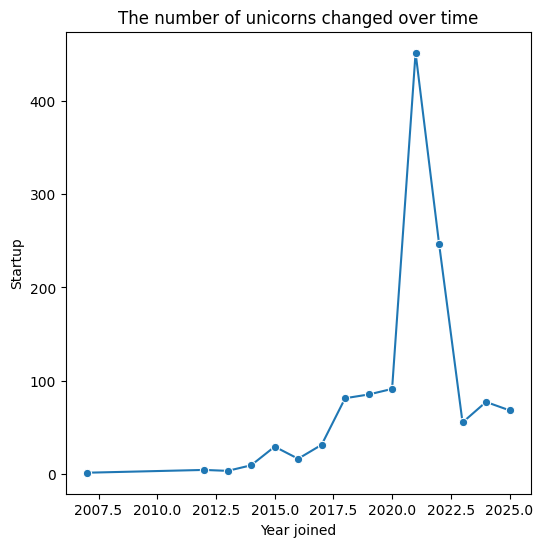

Year had the highest number of new startups: 2021
The Number of Startups: 452


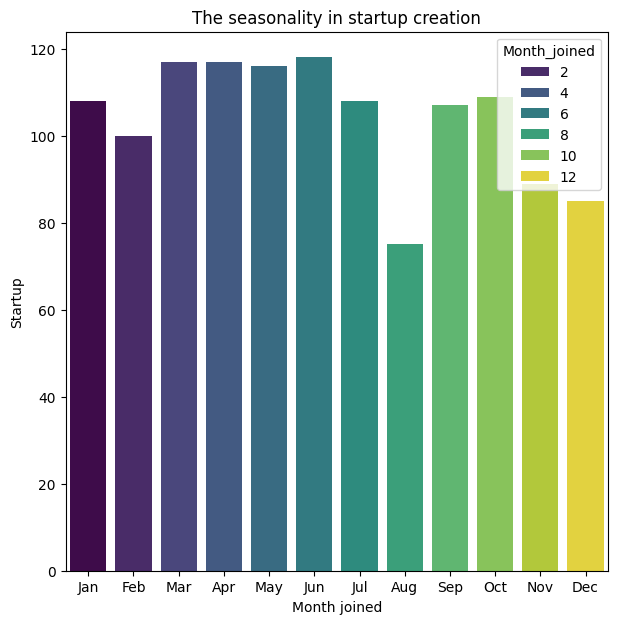

    Year_joined  Startup
0          2007        1
1          2012        4
2          2013        3
3          2014        9
4          2015       29
5          2016       16
6          2017       31
7          2018       81
8          2019       85
9          2020       91
10         2021      452
11         2022      247
12         2023       55
13         2024       77
14         2025       68
    Year_joined  Startup  YoY growth
0          2007        1         NaN
1          2012        4  300.000000
2          2013        3  -25.000000
3          2014        9  200.000000
4          2015       29  222.222222
5          2016       16  -44.827586
6          2017       31   93.750000
7          2018       81  161.290323
8          2019       85    4.938272
9          2020       91    7.058824
10         2021      452  396.703297
11         2022      247  -45.353982
12         2023       55  -77.732794
13         2024       77   40.000000
14         2025       68  -11.688312


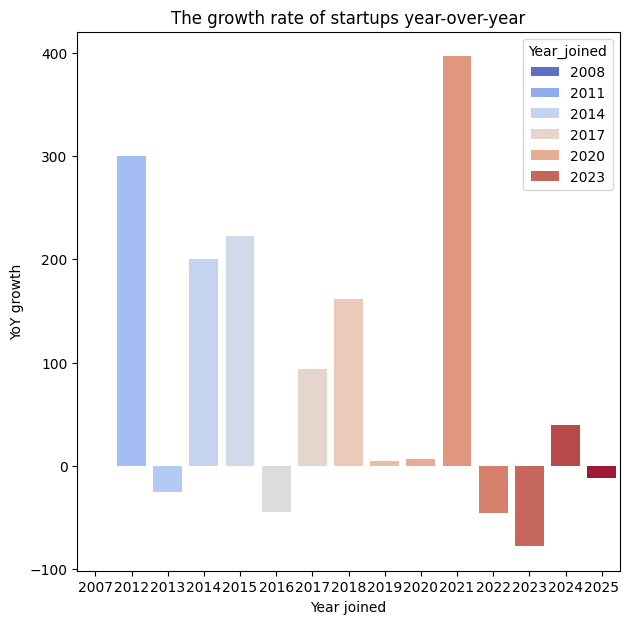

Year with most startups: 2021 → 452 startups
Year with highest growth rate: 2021 → 396.7 % growth


In [7]:
#How has the number of unicorns changed over time?
unicorn1=data.groupby('Year_joined')['Startup'].count().reset_index()
plt.figure(figsize=(6,6))
sns.lineplot(data=unicorn1,x='Year_joined',y='Startup',marker='o')
plt.title('The number of unicorns changed over time')
plt.xlabel('Year joined')
plt.ylabel('Startup')
plt.show()

#.Which year had the highest number of new startups?
max=unicorn1.loc[unicorn1['Startup'].idxmax()]
print('Year had the highest number of new startups:',int(max['Year_joined']))
print("The Number of Startups:",int(max['Startup']))

#Is there seasonality in startup creation?
unicorn2=data.groupby('Month_joined')['Startup'].count().reset_index()
plt.figure(figsize=(7,7))
sns.barplot(data=unicorn2,x='Month_joined',y='Startup',hue='Month_joined',palette="viridis")
plt.title('The seasonality in startup creation')
plt.xlabel('Month joined')
plt.ylabel('Startup')
plt.xticks(range(0,12),
           ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
plt.show()
#How many startups joined each year?
print(unicorn1)

#What is the growth rate of startups year-over-year?
unicorn1['YoY growth']=unicorn1['Startup'].pct_change()*100
print(unicorn1)
plt.figure(figsize=(7,7))
sns.barplot(data=unicorn1,x='Year_joined',y='YoY growth',hue='Year_joined',palette="coolwarm")
plt.title('The growth rate of startups year-over-year')
plt.xlabel('Year joined')
plt.ylabel('YoY growth')
plt.show()
#Did any specific year show a boom (e.g., 2021)?
boom_row=unicorn1.loc[unicorn1['Startup'].idxmax()]
boom_growth=unicorn1.loc[unicorn1['YoY growth'].idxmax()]
print("Year with most startups:", int(boom_row["Year_joined"]),
      "→", int(boom_row["Startup"]), "startups")

print("Year with highest growth rate:", int(boom_growth["Year_joined"]),
      "→", round(boom_growth["YoY growth"],1), "% growth")


###Investor-Based Questions
* 1. Which investors appear most frequently?
* 2. How many investors does the average startup have?
* 3. Do more investors correlate with higher valuation?
* 4. Which investors focus on specific industries?
* 5. Which investors are global vs country-specific?
* 6. Do top investors appear in high-valuation startups?


In [8]:
#Which investors appear most frequently
data=data.copy()
data['Select Investors'] = data['Select Investors'].fillna("")
# Split investor names by comma
data['Investor_List'] = data['Select Investors'].apply(lambda x: [i.strip() for i in x.split(",")] if x != "" else [])
from collections import Counter

all_investors = [inv for sublist in data['Investor_List'] for inv in sublist]
investor_counts = Counter(all_investors)

# Convert to DataFrame for easier viewing
investor_freq = pd.DataFrame(investor_counts.items(), columns=['Investor', 'Frequency']).sort_values(by='Frequency', ascending=False)
print('investors appear most frequently',investor_freq.head(10))

#How many investors does the average startup have?
avg_investor=data['Investor_count'].mean()
print('Investors does the average startup have',avg_investor)

# Correlation between number of investors and valuation
correlation = data['Investor_count'].corr(data['Valuation ($B)'])
print("Correlation:", correlation)
print('A positive correlation (closer to +1) → startups with more investors tend to have higher valuations.')

#Which investors focus on specific industries?
investor_industry = data[['Industry','Investor_List']].explode('Investor_List')

  # Drop blanks
investor_industry = investor_industry[investor_industry['Investor_List'] != ""]
  # Count how many times each investor appears in each industry
industry_focus = (investor_industry
                    .groupby(['Investor_List','Industry'])
                    .size()
                    .reset_index(name='Count')
                    .sort_values(by='Count', ascending=False))
  #investors in each industry
top_investors_by_industry = industry_focus.groupby('Industry')
print(top_investors_by_industry.head(5))

investor_country = data[['Country','Investor_List']].explode('Investor_List')

#Which investors are global vs country-specific?

# Drop blanks
investor_country = investor_country[investor_country['Investor_List'] != ""]
# Count how many unique countries each investor appears in
country_focus = (investor_country
                 .groupby('Investor_List')['Country']
                 .nunique()
                 .reset_index(name='Country_Count'))
# Define global vs country-specific
country_focus['Scope'] = country_focus['Country_Count'].apply(
    lambda x: 'Global' if x > 1 else 'Country-specific'
)
# Add frequency (total startups backed)
investor_freq = (investor_country
                 .groupby('Investor_List')
                 .size()
                 .reset_index(name='Startup_Count'))

investor_scope = pd.merge(country_focus, investor_freq, on='Investor_List')
investor_scope.head(5)


#Do top investors appear in high-valuation startups?
investor_valuation=data[["Startup",'Valuation ($B)','Investor_List']].explode('Investor_List')
investor_valuation=investor_valuation[investor_valuation['Investor_List']!=""]
     # Average valuation of startups backed by each investor
avg_val_by_investor = (investor_valuation
                       .groupby('Investor_List')['Valuation ($B)']
                       .mean()
                       .reset_index()
                       .sort_values(by='Valuation ($B)', ascending=False))
     # Merge with investor frequency (startup count)
investor_scope = pd.merge(investor_scope, avg_val_by_investor, on='Investor_List')

     # Sort by Startup_count or Valuation
investor_scope.sort_values(by=['Startup_Count','Valuation ($B)'], ascending=False).head(10)


investors appear most frequently                         Investor  Frequency
11           Andreessen Horowitz         78
37                         Accel         73
2                Sequoia Capital         66
67       Tiger Global Management         50
59              General Catalyst         47
80              Insight Partners         45
55   Lightspeed Venture Partners         43
6          Sequoia Capital China         38
14                Index Ventures         37
156    Bessemer Venture Partners         33
Investors does the average startup have 2.7726180944755803
Correlation: 0.03178590824360206
A positive correlation (closer to +1) → startups with more investors tend to have higher valuations.
                    Investor_List                    Industry  Count
1630              Sequoia Capital             Enterprise Tech     38
146           Andreessen Horowitz             Enterprise Tech     38
49                          Accel             Enterprise Tech     36
1162  Lightspe

,Investor_List,Country_Count,Scope,Startup_Count,Valuation ($B)
99,Andreessen Horowitz,6,Global,78,5.956026
37,Accel,14,Global,73,3.402603
1100,Sequoia Capital,9,Global,66,11.878636
1248,Tiger Global Management,11,Global,50,2.714000
530,General Catalyst,10,Global,47,2.990426
655,Insight Partners,9,Global,45,2.552444
767,Lightspeed Venture Partners,7,Global,43,3.104884
1101,Sequoia Capital China,6,Global,38,11.921053
646,Index Ventures,11,Global,37,4.572432
183,Bessemer Venture Partners,8,Global,33,1.902424


###Advanced / Insight Questions
   * 1.Is there a relationship between city and valuation?
   * 2.Do startups in major hubs get higher funding?
   * 3.Which combinations of country + industry dominate?
   * 4.What patterns exist in investor networks?
   * 5.Can we cluster startups based on features?
   * 6.Which startups are outliers in valuation?
   * 7.Is there bias toward certain regions or industries?


              City  Average_Valuation  Median_Valuation  Start_up_count
234  San Francisco           8.008454              2.00             194
18         Beijing           7.666667              1.43              60
155         London           4.444783              2.00              46
201          Paris           3.097826              2.00              23
183         Mumbai           3.084615              2.44              13


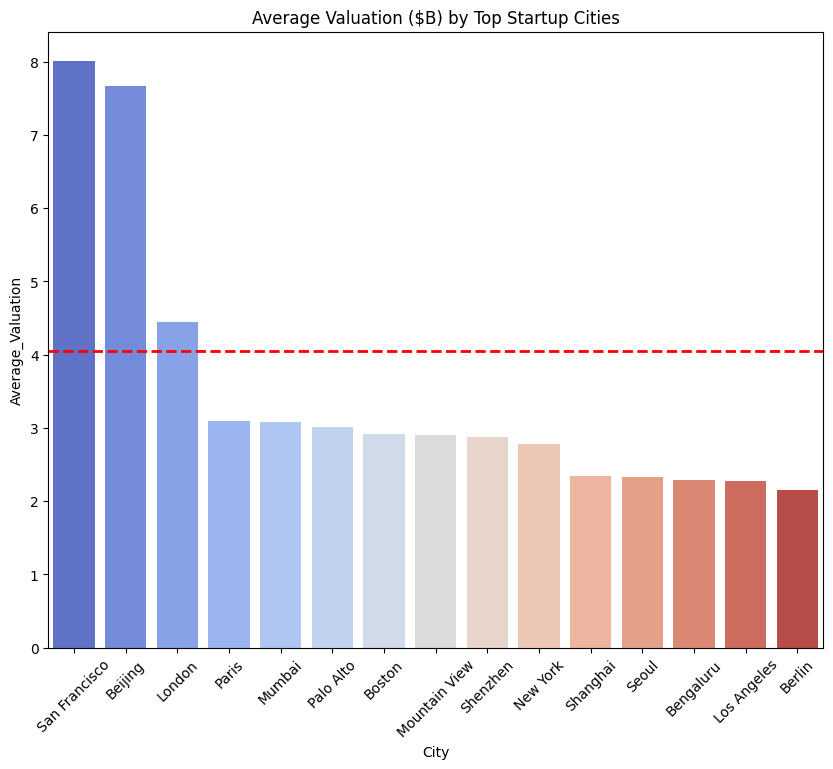

                  mean  median  count      sum
Hub_Type                                      
Mega Hub      7.393667     2.0    300  2218.10
Other Cities  2.997102     1.5    949  2844.25
                     Industry        Country  Startup_Count
0           Consumer & Retail  United States             71
1             Enterprise Tech  United States            305
2          Financial Services  United States            105
3                      Health    Switzerland              1
4  Healthcare & Life Sciences  United States             88
5                 Industrials  United States             83
6                   Insurance  United States             14
7       Media & Entertainment  United States             44


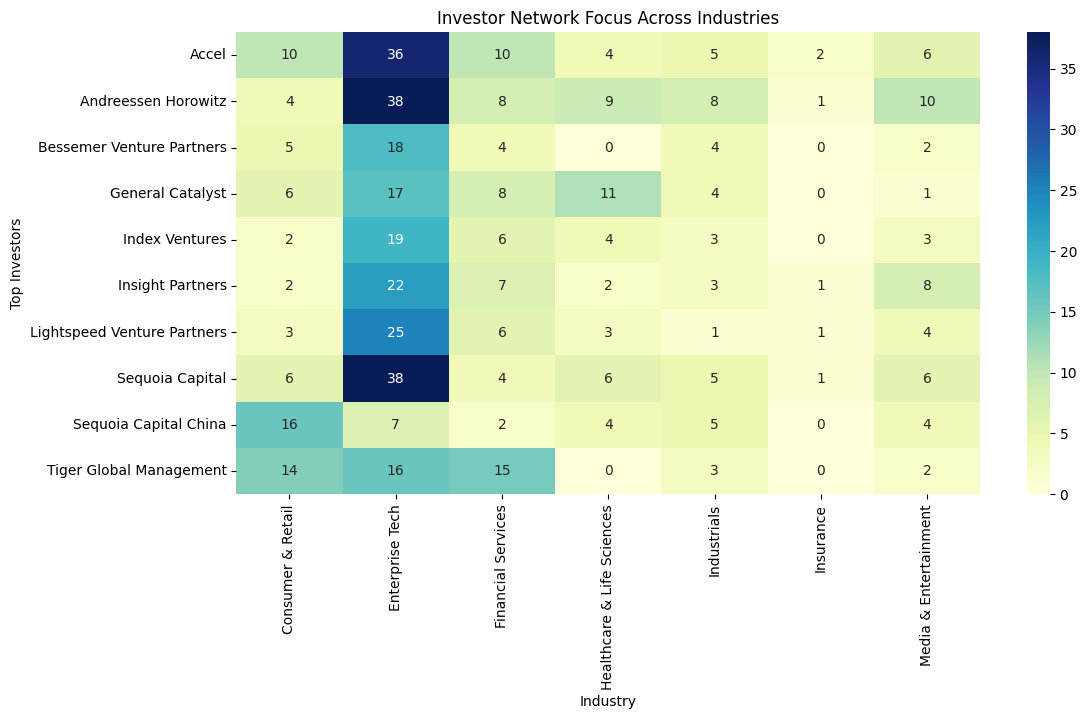

--- Cluster Profiles (Averages) ---
         Valuation ($B)  Startup_age  Investor_count
Cluster                                             
0              4.654134     4.110615        2.776536
1              4.744921     3.596825        2.798186
2              3.633535     4.730078        2.763672
3              2.362222     3.960684        2.709402


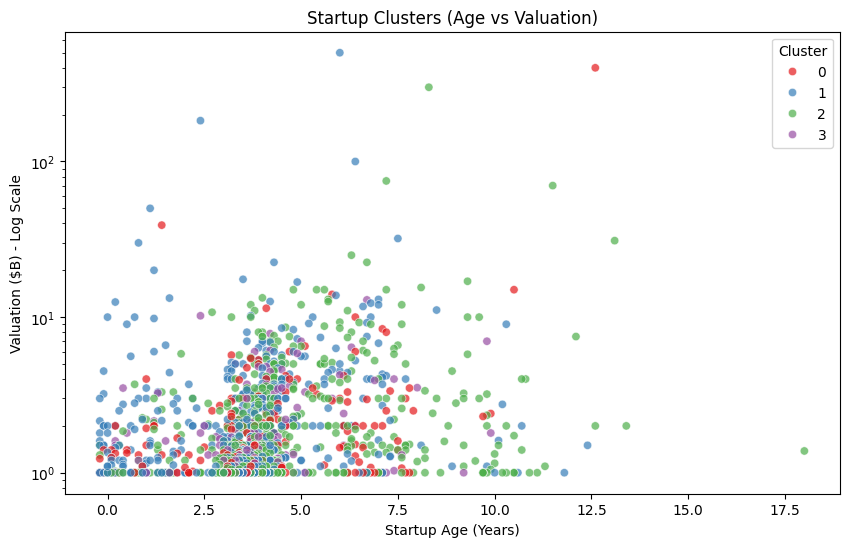

       Startup  Valuation ($B)               Industry           City
0       OpenAI           500.0        Enterprise Tech  San Francisco
1       SpaceX           400.0            Industrials      Hawthorne
2    ByteDance           300.0  Media & Entertainment        Beijing
3    Anthropic           183.0        Enterprise Tech  San Francisco
4   Databricks           100.0        Enterprise Tech  San Francisco
5      Revolut            75.0     Financial Services         London
6       Stripe            70.0     Financial Services  San Francisco
8          xAI            50.0        Enterprise Tech     Burlingame
9       Figure            39.0            Industrials      Sunnyvale
10       Canva            32.0        Enterprise Tech    Surry Hills
Industry  Consumer & Retail  Enterprise Tech  Financial Services  Health  \
Cluster                                                                    
0                         0                0                   0       0   
1            

In [15]:
#Is there a relationship between city and valuation?
  #Calculate average and median valuation per city, along with the startup count
city_valution=data.groupby('City').agg(
    Average_Valuation=('Valuation ($B)','mean'),
    Median_Valuation=('Valuation ($B)','median'),
    Start_up_count=('Startup','count')
).reset_index()
siginificant_hub=city_valution[city_valution['Start_up_count']>10].sort_values(by='Average_Valuation',ascending=False)
print(siginificant_hub.head(5))
plt.figure(figsize=(10,8))
sns.barplot(data=siginificant_hub.head(15),x='City',y='Average_Valuation',hue='City',palette='coolwarm')
plt.axhline(y=4.05, color='red', linestyle='--', linewidth=2, label='Global Average ($4.05B)')
plt.title('Average Valuation ($B) by Top Startup Cities')
plt.xticks(rotation=45)
plt.show()
#Do startups in major hubs get higher funding?
data['Hub_Type']=data['City'].apply(lambda x:'Mega Hub'if x in ['San Francisco', 'Beijing','London'] else 'Other Cities')
hub_comparison=data.groupby('Hub_Type')['Valuation ($B)'].agg(['mean','median','count','sum'])
print(hub_comparison)
#Which combinations of country + industry dominate?
industry_country_counts = (
    data.groupby(["Industry", "Country"])
      .size()
      .reset_index(name="Startup_Count")
)

# For each industry, find the country with the maximum startups
lead_country = (
    industry_country_counts.loc[
        industry_country_counts.groupby("Industry")["Startup_Count"].idxmax()
    ]
    .reset_index(drop=True))
print(lead_country)

# Create a pivot table of Top 10 Investors vs Industries
# Add frequency (total startups backed)
investor_freq = (investor_country
                 .groupby('Investor_List')
                 .size()
                 .reset_index(name='Startup_Count'))
top_10_investors = investor_freq.sort_values(by='Startup_Count', ascending=False).head(10)['Investor_List'].tolist()
filtered_network = industry_focus[industry_focus['Investor_List'].isin(top_10_investors)]

network_pivot = filtered_network.pivot_table(index='Investor_List', columns='Industry', values='Count', fill_value=0)

plt.figure(figsize=(12, 6))
sns.heatmap(network_pivot, annot=True, cmap='YlGnBu', fmt='g')
plt.title('Investor Network Focus Across Industries')
plt.ylabel('Top Investors')
plt.xlabel('Industry')
plt.show()

#Can we cluster startups based on features?
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Select features and convert text industries into numbers automatically
features = ['Valuation ($B)', 'Startup_age', 'Investor_count', 'Industry']
X = pd.get_dummies(data[features], columns=['Industry'], drop_first=True)

# 2. Scale the data (essential for K-Means to work properly)
X_scaled = StandardScaler().fit_transform(X)

# 3. Create 4 natural groups (clusters)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
data['Cluster'] = kmeans.fit_predict(X_scaled)

# 4. Print the average profile of each cluster
print("--- Cluster Profiles (Averages) ---")
print(data.groupby('Cluster')[['Valuation ($B)', 'Startup_age', 'Investor_count']].mean())

# 5. Plot the clusters visually
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='Startup_age', y='Valuation ($B)', hue='Cluster', palette='Set1', alpha=0.7)
plt.yscale('log')  # Uses a log scale to cleanly handle huge outliers like OpenAI
plt.title('Startup Clusters (Age vs Valuation)')
plt.xlabel('Startup Age (Years)')
plt.ylabel('Valuation ($B) - Log Scale')
plt.show()

#Which startups are outliers in valuation?
outliers=data.sort_values(by='Valuation ($B)',ascending=False)
print(outliers[['Startup','Valuation ($B)','Industry','City']].head(10))



# Count startups per cluster by industry
industry_bias = pd.crosstab(data['Cluster'], data['Industry'])

print(industry_bias)


In [10]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# -------------------------------------------------------------------------
# STORY CHAPTER 1: The Extreme Regional Concentration
# -------------------------------------------------------------------------
country_counts = (
    data["Country"].value_counts().reset_index(name="Unicorn Count")
)
country_vals = (
    data.groupby("Country")["Valuation ($B)"].sum().reset_index(name="Total Value")
)
geo_data = country_counts.merge(country_vals, on="Country")

fig1 = px.choropleth(
    geo_data,
    locations="Country",
    locationmode="country names",
    color="Unicorn Count",
    hover_name="Country",
    hover_data=["Total Value"],
    color_continuous_scale="Viridis",
    title="<b>Chapter 1: The Global Geography Bias</b><br><sup>The US and China completely dominate global unicorn density, leaving most regions empty.</sup>",
)
fig1.update_layout(
    template="plotly_white", margin=dict(l=0, r=0, t=80, b=0), height=500
)
fig1.show()


# -------------------------------------------------------------------------
# STORY CHAPTER 2: The Tech Monopoly Tree
# -------------------------------------------------------------------------
industry_summary = (
    data.groupby("Industry")
    .agg(Count=("Startup", "count"), Avg_Valuation=("Valuation ($B)", "mean"))
    .reset_index()
)

fig2 = px.treemap(
    industry_summary,
    path=[px.Constant("Global Ecosystem"), "Industry"],
    values="Count",
    color="Avg_Valuation",
    color_continuous_scale="RdPu",
    title="<b>Chapter 2: Industrial Specialization & Bias</b><br><sup>Enterprise Tech commands over 35% of all unicorn slots, while software sectors carry the highest average valuations.</sup>",
)
fig2.update_traces(textinfo="label+value+percent parent")
fig2.update_layout(template="plotly_white", height=500)
fig2.show()


# -------------------------------------------------------------------------
# STORY CHAPTER 3: The Historical 2021 Spike and Funding Correction
# -------------------------------------------------------------------------
timeline = (
    data.groupby("Year_joined")
    .agg(Count=("Startup", "count"), Total_Val=("Valuation ($B)", "sum"))
    .reset_index()
)

# Filtering from 2014 onwards for cleaner storytelling visualization
timeline = timeline[timeline["Year_joined"] >= 2014]

fig3 = make_subplots(specs=[[{"secondary_y": True}]])

fig3.add_trace(
    go.Bar(
        x=timeline["Year_joined"],
        y=timeline["Count"],
        name="New Unicorns Joined",
        marker_color="#1f77b4",
        opacity=0.75,
    ),
    secondary_y=False,
)

fig3.add_trace(
    go.Scatter(
        x=timeline["Year_joined"],
        y=timeline["Total_Val"],
        name="Total Value Added ($B)",
        line=dict(color="#ff7f0e", width=3),
        mode="lines+markers",
    ),
    secondary_y=True,
)

fig3.update_layout(
    title="<b>Chapter 3: The 2021 Hyper-Inflation Wave</b><br><sup>A massive anomaly occurred in 2021 when 452 new unicorns minting broke all historic venture capital baselines.</sup>",
    xaxis_title="Year Joined",
    template="plotly_white",
    legend=dict(x=0.02, y=0.98),
    height=500,
)

fig3.update_yaxes(title_text="Number of Startups", secondary_y=False)
fig3.update_yaxes(title_text="Total Valuation Added ($B)", secondary_y=True)
fig3.show()


# -------------------------------------------------------------------------
# STORY CHAPTER 4: The Power Law Distribution (Outliers)
# -------------------------------------------------------------------------
# Tag top 5 outliers specifically to make the graph highly interactive and readable
top_outliers = data.nlargest(5, "Valuation ($B)")

fig4 = px.scatter(
    data,
    x="Startup_age",
    y="Valuation ($B)",
    color="Industry",
    size="Valuation ($B)",
    hover_name="Startup",
    hover_data=["City", "Country"],
    log_y=True,  # Logarithmic scale handles extreme valuation distribution skew beautifully
    title="<b>Chapter 4: The Extreme Power Law Scatter</b><br><sup>While the global median is just $1.6B, mega-outliers like OpenAI ($500B) stretch the market limits.</sup>",
)

# Explicitly annotate the top 3 global outliers
for idx, row in top_outliers.head(3).iterrows():
    fig4.add_annotation(
        x=row["Startup_age"],
        y=row["Valuation ($B)"],
        text=f"{row['Startup']} (${row['Valuation ($B)']}B)",
        showarrow=True,
        arrowhead=2,
        ax=40,
        ay=-30,
        font=dict(size=10, color="black"),
        bgcolor="white",
        bordercolor="gray",
    )

fig4.update_layout(
    xaxis_title="Startup Age (Years since joining Unicorn Club)",
    yaxis_title="Valuation ($B) - Log Scale",
    template="plotly_white",
    height=600,
)
fig4.show()